**Estados de Bell**

Aqui vamos mostrar como é construido os estados de Bell através do Qiskit. Para isso, vamos considerar um sistema de dois qubits. Como explicado nos slides, o estado de Bell é alcançado com a utilização das portas quânticas Hadamard e CNOT. Mas antes, é necessário construir um circuito com 2 qubits e 2 bits clássicos registradores.

Primeiramente, instala as bibliotecas necessárias.

In [1]:
!pip install qiskit[visualization]==1.2.2
!pip install qiskit_aer
!pip install qiskit_ibm_runtime
!pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 4.6 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136816 sha256=a03995772c0df5c9d2824d07d185fab711dbaf86a48bc0c8b63a512494fe4100
  Stored in directory: /root/.cache/pip/wheels/b1/7a/33/9fdd892f784ed4afda62b685ae3703adf4c91aa0f524c28f03
Successfully built pylatexenc
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 94.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import qiskit
from qiskit import QuantumCircuit, transpile
from qiskit import QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import qiskit.quantum_info as qi
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler

In [3]:
# Cria os registros para a criação dos qubits e bits
qr = QuantumRegister(2)
cr = ClassicalRegister(2)

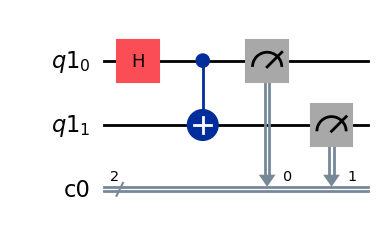

In [4]:
# Cria o circuito e faz o emaranhamento criando os estados de Bell
circuit = QuantumCircuit(qr, cr)
circuit.h(qr[0])
circuit.cx(qr[0], qr[1])
circuit.measure(qr, cr)
circuit.draw('mpl')

A seguir, será feito os cálculos para criar o primeiro estado de Bell utilizando o processamento dos computadores quânticos reais da IBM. Para isso é necessário um criar uma conta no site oficial da IBM e copiar um token de acesso para poder utilizar os dispositivos quânticos.


In [5]:
### Save API Token, if needed
%set_env QXToken=efb74e352212e30f8c940f1324fda81d0a099860fe2fe0dc411eb8154a3ac34e5f2a34b2fb2188197627a367652f83bd0c55763125b13f64f3b8b0a6f66c46fc

env: QXToken=efb74e352212e30f8c940f1324fda81d0a099860fe2fe0dc411eb8154a3ac34e5f2a34b2fb2188197627a367652f83bd0c55763125b13f64f3b8b0a6f66c46fc


In [6]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(channel="ibm_quantum", # ibm_cloud
                               token = '39096e7a3b61144409089599e4a7c833fb42342fe2cfec9e66a416c322927860ac402202d87a09efdedb7eaafb98a5874bbf2def57ee0b6354c27878e2baa3da')

In [7]:
QiskitRuntimeService.save_account(channel='ibm_quantum',
                                  token = '39096e7a3b61144409089599e4a7c833fb42342fe2cfec9e66a416c322927860ac402202d87a09efdedb7eaafb98a5874bbf2def57ee0b6354c27878e2baa3da',
                                  overwrite=True)

In [8]:
backend = service.least_busy(operational=True, simulator=False)

In [9]:
#Fazer a conta no computador quãntico da IBM. O cálculo fica numa fila para ser executado.
pm = generate_preset_pass_manager(backend=backend, optimization_level=2)
isa_circuit = pm.run(circuit)

Counts: {'01': 42, '00': 2023, '11': 1975, '10': 56}


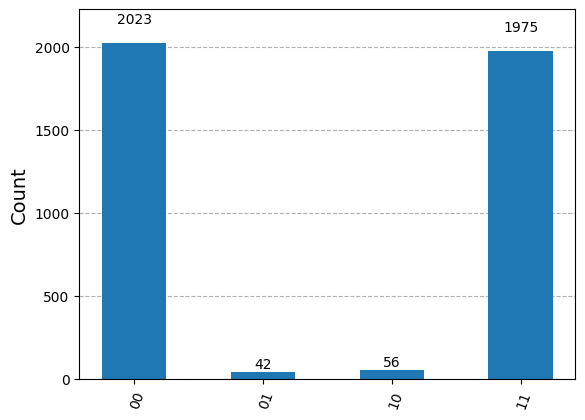

In [10]:
#Em seguida uma amostragem é realizada e o resultado é apresentado
sampler = Sampler(backend)
job = sampler.run([(isa_circuit)])
result = job.result()
pub_result = result[0]
counts = pub_result.data.c0.get_counts()
print("Counts:", counts)
plot_histogram(counts)

Configurado o circuito no Jupyter Notebook, o gráfico com as probabilidades pode ser plotado. Note que, a figura mostra a documentação dos estados |01> e |10> com probabilidades pequenas. Mesmo que os estados de Bell sejam maximamente emaranhados, a detecção desses estados se deve ao fato de os computadores quânticos disponíveis serem suscetíveis a erros e ruídos no momento da execução do código. Existe um esforço no avanço da tecnologia de hardware quântico com intuito de diminuir esse erros a fim do resultado se tornar cada vez
mais próximo à simulação. No entanto, é possível utilizar métodos de correção de erros para obtenção de resultados mais fiéis.
